# QuantumPINNs — Tutorial 2: Physics-Informed Neural Networks for the Time-Dependent Schrödinger Equation

## Welcome & Learning Objectives

This notebook is a **self-contained, step-by-step tutorial** on solving the **Time-Dependent Schrödinger Equation (TDSE)** with Physics-Informed Neural Networks (PINNs). By the end you will be able to:

1. Understand why the TDSE requires a *complex-valued* PDE solver and how to handle this in PyTorch.
2. Implement a dual-output (`ψ_r`, `ψ_i`) PINN with hard boundary conditions.
3. Verify the solution quantitatively using **Ehrenfest's theorem**, **probability current**, and **phase**.
4. Appreciate the role of each loss term and tune the λ weights.

---

## Table of Contents

| # | Section | Key Concepts |
|---|---------|-------------|
| 1 | **Exact Gaussian Wavepacket** | Free-particle propagator, wavepacket spreading, norm |
| 2 | **ComplexPINN Architecture** | Dual-head network, hard BC envelope, Xavier init |
| 3 | **TDSE Residuals & Loss** | Autograd ∂/∂t & ∂²/∂x², composite loss, IC/norm terms |
| 4 | **Training & Convergence** | Adam + MultiStepLR, loss decomposition, balance monitoring |
| 5 | **Spacetime Density Maps** | ρ(x,t) heatmap, classical trajectory overlay, error maps |
| 6 | **Probability Current J(x,t)** | Continuity equation, norm conservation table |
| 7 | **Ehrenfest Theorem** | ⟨x⟩(t), ⟨p⟩(t) vs classical analogue, norm drift |
| 8 | **Phase θ(x,t) and Wavenumber** | arg ψ, unwrapping, local k(x,t) = ∂θ/∂x |

---

## Mathematical Framework

The **Time-Dependent Schrödinger Equation (TDSE)** in one spatial dimension (with $\hbar = m = 1$):

$$i\frac{\partial\psi}{\partial t} = \hat{H}\psi = \left[-\frac{1}{2}\frac{\partial^2}{\partial x^2} + V(x)\right]\psi(x,t)$$

Since $\psi \in \mathbb{C}$, we split into real and imaginary parts $\psi = \psi_r + i\psi_i$ yielding two **coupled real PDEs**:

$$\frac{\partial\psi_r}{\partial t} = -\frac{1}{2}\frac{\partial^2\psi_i}{\partial x^2} + V(x)\psi_i$$

$$\frac{\partial\psi_i}{\partial t} = +\frac{1}{2}\frac{\partial^2\psi_r}{\partial x^2} - V(x)\psi_r$$

> **Key insight**: the two equations are *coupled* — the real part evolves according to the spatial curvature of the imaginary part, and vice versa. A PINN must capture this coupling exactly via shared collocation points and simultaneous gradients.

### Madelung Representation

Writing $\psi = \sqrt{\rho}\,e^{i\theta}$ where $\rho=|\psi|^2$ is the probability density and $\theta = \arctan(\psi_i/\psi_r)$ is the phase, the TDSE becomes the **Madelung equations** (quantum hydrodynamics):

$$\frac{\partial\rho}{\partial t} + \frac{\partial}{\partial x}\left(\rho\frac{\partial\theta}{\partial x}\right) = 0 \quad \text{(continuity)}$$

$$\frac{\partial\theta}{\partial t} + \frac{1}{2}\left(\frac{\partial\theta}{\partial x}\right)^2 + V - \underbrace{\frac{1}{2\sqrt{\rho}}\frac{\partial^2\sqrt{\rho}}{\partial x^2}}_{Q = \text{Bohm quantum potential}} = 0 \quad \text{(quantum Euler)}$$

The quantum potential $Q$ has no classical analogue — it gives rise to interference and tunneling.

### Probability Current

The **probability current density** describes the *flow* of probability along $x$:

$$J(x,t) = \text{Im}\!\left(\psi^*\frac{\partial\psi}{\partial x}\right) = \psi_r\frac{\partial\psi_i}{\partial x} - \psi_i\frac{\partial\psi_r}{\partial x}$$

satisfying the **continuity equation** $\frac{\partial\rho}{\partial t} + \frac{\partial J}{\partial x} = 0$.  
This is a *conservation law* — if the PINN satisfies the TDSE exactly, $J$ will satisfy it automatically. We use deviations from continuity as a diagnostic.

### Ehrenfest Theorem

Quantum expectation values obey *classical* equations of motion:

$$\frac{d\langle x\rangle}{dt} = \langle p\rangle, \qquad \frac{d\langle p\rangle}{dt} = -\left\langle \frac{\partial V}{\partial x}\right\rangle$$

For $V=0$ (free particle): $\langle x\rangle(t) = x_0 + k_0 t$ and $\langle p\rangle(t) = k_0$ (constant). This gives us an **independent accuracy check** — after training, we compute $\langle x\rangle$ and $\langle p\rangle$ from the PINN output and compare to the classical prediction.

### PINN Formulation

We train a two-headed network $(\hat\psi_r, \hat\psi_i)(x,t;\theta)$ to minimize:

$$\mathcal{L} = \underbrace{\mathcal{L}_{\text{PDE},r} + \mathcal{L}_{\text{PDE},i}}_{\text{TDSE residuals}} + \lambda_{\text{ic}}\underbrace{\mathcal{L}_{\text{IC}}}_{\text{initial condition}} + \lambda_{\text{norm}}\underbrace{\mathcal{L}_{\text{norm}}}_{\|\psi\|^2=1 \text{ at sampled }t}$$

$$\mathcal{L}_{\text{PDE},r} = \frac{1}{N_c}\sum_{i}\left|\frac{\partial\hat\psi_r}{\partial t} + \frac{1}{2}\frac{\partial^2\hat\psi_i}{\partial x^2} - V\hat\psi_i\right|^2$$

$$\mathcal{L}_{\text{PDE},i} = \frac{1}{N_c}\sum_{i}\left|\frac{\partial\hat\psi_i}{\partial t} - \frac{1}{2}\frac{\partial^2\hat\psi_r}{\partial x^2} + V\hat\psi_r\right|^2$$

### Benchmark: Gaussian Wavepacket (Free Particle, $V=0$)

A coherent state centered at $x_0$ with momentum $k_0$ and width $\sigma$:

$$\psi(x, 0) = \frac{1}{(\pi\sigma^2)^{1/4}}\exp\!\left(-\frac{(x-x_0)^2}{2\sigma^2} + ik_0 x\right)$$

The **exact** time-evolved solution is:

$$\psi(x,t) = \frac{1}{(\pi)^{1/4}\sqrt{\sigma + it/\sigma}}\exp\!\left[-\frac{(x-x_0-k_0 t)^2}{2\sigma(\sigma+it/\sigma)} + ik_0 x - \frac{ik_0^2 t}{2}\right]$$

Key observables: center travels classically $\langle x\rangle(t) = x_0 + k_0 t$; width spreads as $\sigma(t) = \sqrt{\sigma^2 + t^2/\sigma^2}$ (quantum *dispersion*).

> We use this exact solution to **supervise the initial condition** at $t=0$ and **validate** the PINN prediction over the full spacetime domain.

/var/folders/lh/_lmy47y97yqbjdwcr5k2k9rh0000gp/T/ipykernel_41609/3313818558.py:41: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap_psi = cm.get_cmap('plasma')


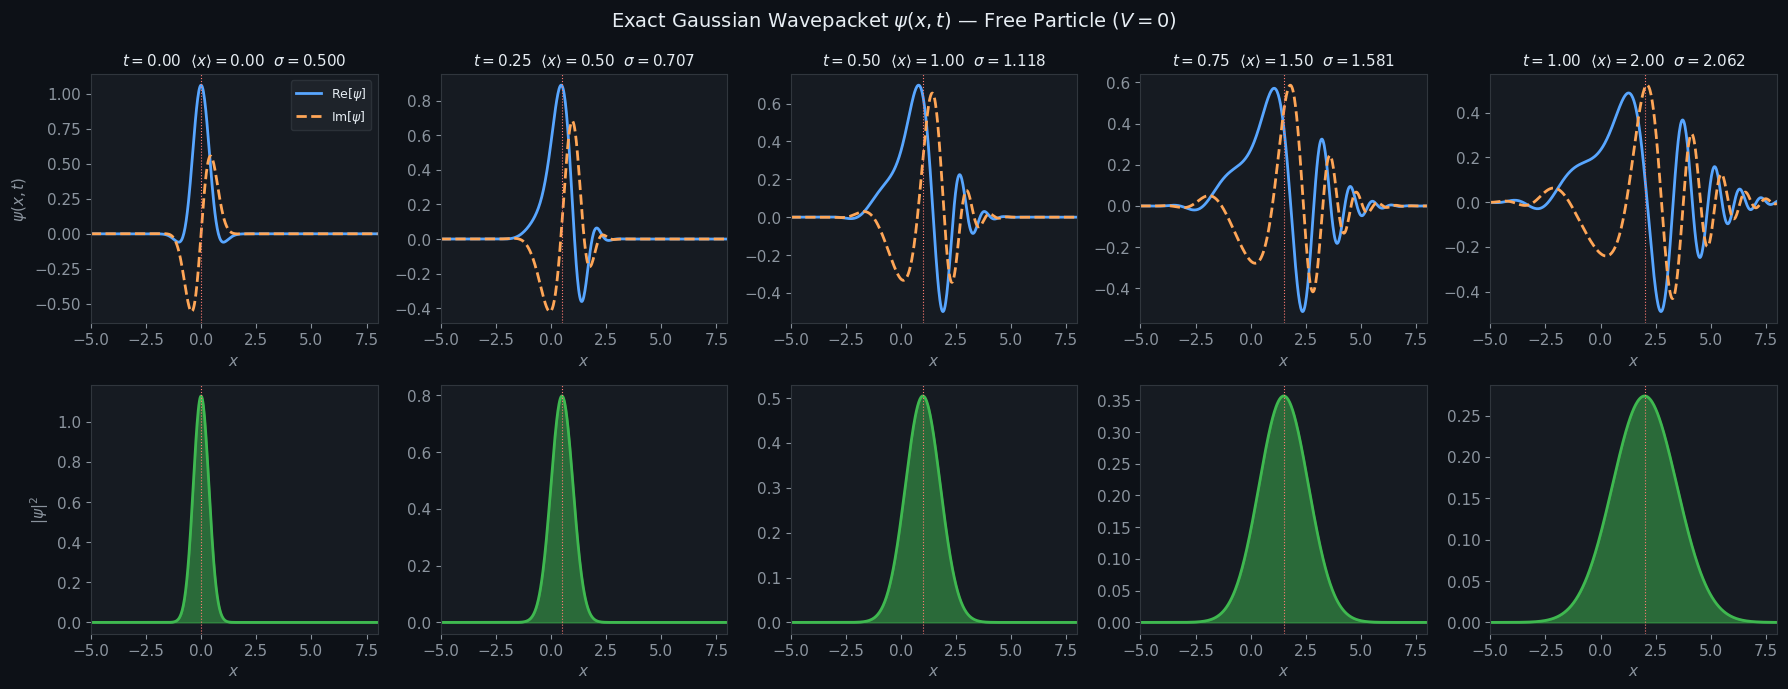

Saved → outputs/schrodinger_exact_snapshots.png
Wavepacket parameters: x0=0.0, k0=2.0, σ₀=0.5
Width at t=1.0: σ(1)=2.0616  (σ₀=0.5)


AttributeError: module 'numpy' has no attribute 'trapz'

In [1]:
import numpy as np
import torch
import torch.nn as nn
import matplotlib.pyplot as plt
import matplotlib.cm as cm
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
import os

plt.style.use('dark_background')
plt.rcParams.update({
    'figure.facecolor': '#0d1117', 'axes.facecolor': '#161b22',
    'axes.edgecolor': '#30363d',   'grid.color': '#21262d',
    'text.color': '#e6edf3',       'axes.labelcolor': '#8b949e',
    'xtick.color': '#8b949e',      'ytick.color': '#8b949e',
    'font.size': 11, 'axes.titlesize': 13,
})

torch.manual_seed(42)
np.random.seed(42)
os.makedirs('../outputs', exist_ok=True)

# ─── Exact Gaussian wavepacket solution (free particle, V=0) ────────────────
def exact_wavepacket(x, t, x0=0.0, k0=2.0, sigma=0.5):
    """Exact free-particle Gaussian wavepacket. Returns (psi_r, psi_i)."""
    x, t = np.asarray(x), np.asarray(t)
    sigma_t = sigma + 1j * t / sigma         # complex width
    norm    = (np.pi)**0.25 * np.sqrt(sigma_t)
    exponent = -(x - x0 - k0*t)**2 / (2 * sigma * sigma_t) + 1j * k0 * x - 0.5j * k0**2 * t
    psi     = np.exp(exponent) / norm
    return np.real(psi), np.imag(psi)

# Plot the exact wavepacket at several times
t_snaps = [0.0, 0.25, 0.5, 0.75, 1.0]
x_arr   = np.linspace(-5, 8, 500)
x0, k0, sigma = 0.0, 2.0, 0.5

fig, axes = plt.subplots(2, len(t_snaps), figsize=(18, 7), facecolor='#0d1117')
fig.suptitle('Exact Gaussian Wavepacket $\\psi(x,t)$ — Free Particle ($V=0$)', color='#e6edf3', fontsize=14)

cmap_psi = cm.get_cmap('plasma')
for j, t_j in enumerate(t_snaps):
    psi_r, psi_i = exact_wavepacket(x_arr, t_j, x0, k0, sigma)
    rho  = psi_r**2 + psi_i**2
    # Centre and width tracking
    xc   = x0 + k0 * t_j
    sig_t = np.sqrt(sigma**2 + t_j**2 / sigma**2)

    ax_top = axes[0, j]
    ax_top.set_facecolor('#161b22')
    for sp in ax_top.spines.values(): sp.set_edgecolor('#30363d')
    ax_top.plot(x_arr, psi_r, '-', color='#58a6ff', lw=2,   label=r'Re[$\psi$]')
    ax_top.plot(x_arr, psi_i, '--', color='#ffa657', lw=2,  label=r'Im[$\psi$]')
    ax_top.axvline(xc, color='#ff7b72', lw=0.8, ls=':')
    ax_top.set_title(f'$t={t_j:.2f}$  $⟨x⟩={xc:.2f}$  $σ={sig_t:.3f}$', color='#e6edf3', fontsize=11)
    ax_top.set_xlabel('$x$', color='#8b949e')
    ax_top.set_xlim(-5, 8)
    if j == 0:
        ax_top.set_ylabel(r'$\psi(x,t)$', color='#8b949e')
        ax_top.legend(facecolor='#21262d', edgecolor='#30363d', labelcolor='#e6edf3', fontsize=9)

    ax_bot = axes[1, j]
    ax_bot.set_facecolor('#161b22')
    for sp in ax_bot.spines.values(): sp.set_edgecolor('#30363d')
    ax_bot.fill_between(x_arr, rho, alpha=0.5, color='#3fb950')
    ax_bot.plot(x_arr, rho, '-', color='#3fb950', lw=2)
    ax_bot.axvline(xc, color='#ff7b72', lw=0.8, ls=':')
    ax_bot.set_xlabel('$x$', color='#8b949e')
    ax_bot.set_xlim(-5, 8)
    if j == 0:
        ax_bot.set_ylabel(r'$|\psi|^2$', color='#8b949e')

plt.tight_layout()
plt.savefig('../outputs/schrodinger_exact_snapshots.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved → outputs/schrodinger_exact_snapshots.png')
print(f'Wavepacket parameters: x0={x0}, k0={k0}, σ₀={sigma}')
print(f'Width at t=1.0: σ(1)={np.sqrt(sigma**2 + 1/sigma**2):.4f}  (σ₀={sigma})')
print(f'Norm at t=0: {np.trapezoid(exact_wavepacket(x_arr,0)[0]**2 + exact_wavepacket(x_arr,0)[1]**2, x_arr):.6f}')

In [ ]:
# ══════════════════════════════════════════════════════════════════════════
#  TUTORIAL MODE — controls training speed throughout this notebook
#
#  TUTORIAL_MODE = True  →  epochs scaled to ~8% for fast demo (~3-5 min)
#  TUTORIAL_MODE = False →  full training for publication-quality results
# ══════════════════════════════════════════════════════════════════════════
TUTORIAL_MODE = True
_SCALE = 0.08   # epoch scale factor

def T(n_epochs: int) -> int:
    """Scale epoch count for tutorial — returns at least 50 epochs."""
    return n_epochs if not TUTORIAL_MODE else max(50, int(n_epochs * _SCALE))

print(f'TUTORIAL_MODE={TUTORIAL_MODE}  |  epoch scale={_SCALE}')
print(f'Example: T(6000) = {T(6000)},  T(1500) = {T(1500)}')

In [ ]:
# ── ComplexPINN Architecture: Dual-Output Real/Imaginary Network ──────────
#
# Why dual-head?
#   The TDSE has a *complex* solution ψ = ψ_r + iψ_i. Rather than a complex
#   network (which requires complex-valued autograd), we model both components
#   with a shared trunk and two independent linear heads. This is mathematically
#   equivalent but much simpler to implement in PyTorch.
#
# Hard boundary conditions:
#   We enforce ψ(x=±L, t) = 0 by multiplying the network output by an
#   envelope (1 − x_normalised²) that vanishes exactly at the domain walls.
#   This is called a "hard BC" and removes the need for a boundary loss term.
#
# Xavier initialisation:
#   For tanh activations, Xavier (Glorot) init keeps activation variances ≈1
#   across layers, preventing vanishing/exploding gradients early in training.

class ComplexPINN(nn.Module):
    """
    Two-headed network for TDSE: shared trunk, separate heads for ψ_r and ψ_i.

    Architecture:
        Input (x, t) ─→ Shared trunk [Linear → Tanh] × n_layers ─→ ψ_r head
                                                                   ↘ ψ_i head
    Hard BC: multiply outputs by (1 − (x_normalised)²) so ψ = 0 at walls.
    """
    def __init__(self, hidden=64, n_layers=5, x_domain=(-5.0, 8.0)):
        super().__init__()
        self.x_min, self.x_max = x_domain
        act = nn.Tanh()
        # Shared trunk
        trunk = [nn.Linear(2, hidden), act]
        for _ in range(n_layers - 2):
            trunk += [nn.Linear(hidden, hidden), act]
        self.trunk = nn.Sequential(*trunk)
        # Two independent heads
        self.head_r = nn.Linear(hidden, 1)
        self.head_i = nn.Linear(hidden, 1)

        for m in self.modules():
            if isinstance(m, nn.Linear):
                nn.init.xavier_normal_(m.weight)
                nn.init.zeros_(m.bias)

    def bc_envelope(self, x):
        """Smooth window function: equals 1 at centre, 0 at domain walls."""
        L = (self.x_max - self.x_min) / 2.0
        x_c = (x - (self.x_max + self.x_min) / 2.0) / L   # map to [-1, 1]
        return (1.0 - x_c**2).clamp(min=0.0)

    def forward(self, x, t):
        xt    = torch.cat([x, t], dim=-1)
        feat  = self.trunk(xt)
        psi_r = self.head_r(feat) * self.bc_envelope(x)
        psi_i = self.head_i(feat) * self.bc_envelope(x)
        return psi_r, psi_i

    def probability_density(self, x, t):
        psi_r, psi_i = self.forward(x, t)
        return psi_r**2 + psi_i**2

# ── Domain Setup ─────────────────────────────────────────────────────────
#
# The domain x ∈ [−5, 8] covers ≈ 2 standard deviations of the wavepacket
# at t=1 (when it has drifted to x ≈ 2 with σ(1) ≈ 2.06).
# The time domain t ∈ [0, 1] captures one full drift cycle.
#
# Collocation points:
#   N_interior = random (x,t) pairs inside the domain where the PDE residual
#                is minimised. More points → better random coverage of the domain.
#   N_ic       = points at t=0 where the IC ψ(x,0) is imposed.
#   N_bc       = points at x=X_MIN and x=X_MAX where ψ=0 is imposed (soft).
#                Without the bc_envelope hard BC, we'd need many more.

X_MIN, X_MAX = -5.0, 8.0
T_MIN, T_MAX = 0.0, 1.0
x0, k0, sigma = 0.0, 2.0, 0.5

# ─ TUTORIAL_MODE: reduce collocation count for fast demo ─────────────────
N_interior = 1500 if TUTORIAL_MODE else 4000   # Interior PDE collocation
N_ic       = 300  if TUTORIAL_MODE else 500    # Initial condition (t=0) points
N_bc       = 100  if TUTORIAL_MODE else 200    # Boundary points (soft constraint)

torch.manual_seed(42)

# Interior: random (x, t) in domain
x_int = torch.rand(N_interior, 1) * (X_MAX - X_MIN) + X_MIN
t_int = torch.rand(N_interior, 1) * (T_MAX - T_MIN) + T_MIN

# Initial condition: t=0, random x
x_ic = torch.rand(N_ic, 1) * (X_MAX - X_MIN) + X_MIN
t_ic = torch.zeros(N_ic, 1)
psi_r_ic_exact, psi_i_ic_exact = exact_wavepacket(x_ic.numpy(), 0.0, x0, k0, sigma)
psi_r0 = torch.tensor(psi_r_ic_exact, dtype=torch.float32)
psi_i0 = torch.tensor(psi_i_ic_exact, dtype=torch.float32)

# Evaluating norm at t=0 for reference
x_eval  = torch.linspace(X_MIN, X_MAX, 512).unsqueeze(1)
pr, pi  = exact_wavepacket(x_eval.numpy().flatten(), 0.0, x0, k0, sigma)
rho_ic  = pr**2 + pi**2
norm_ic = np.trapezoid(rho_ic, x_eval.numpy().flatten())
print(f'Initial norm (exact) ∫|ψ|²dx = {norm_ic:.5f}  (should be ≈1)')

# Instantiate model
model   = ComplexPINN(hidden=64, n_layers=5, x_domain=(X_MIN, X_MAX))
n_params = sum(p.numel() for p in model.parameters())
print(f'\nComplexPINN (hidden=64, layers=5): {n_params:,} parameters')
print(f'  Shared trunk: {5-1} × Linear(64,64)+Tanh + input Linear(2,64)+Tanh')
print(f'  Two heads: Linear(64,1) each for ψ_r and ψ_i')
print(f'Domain: x ∈ [{X_MIN}, {X_MAX}], t ∈ [{T_MIN}, {T_MAX}]')
print(f'Collocation: {N_interior} interior, {N_ic} IC, {N_bc} BC points')
print(f'  (TUTORIAL_MODE={TUTORIAL_MODE}: interior was 4000, now {N_interior})')

In [ ]:
# ── TDSE Residual Computation ─────────────────────────────────────────────
#
# How does autograd handle a PDE involving both space and time?
#
#   Step 1: Mark x and t as requires_grad=True (tell PyTorch to track them).
#   Step 2: Forward pass → compute ψ_r(x,t) and ψ_i(x,t) via the network.
#   Step 3: grad(ψ_r.sum(), t) gives dψ_r/dt at every collocation point.
#   Step 4: grad(dψ_r/dx.sum(), x) gives d²ψ_r/dx² (second spatial derivative).
#   Step 5: Plug into the coupled PDE to get the residual.
#
# The key detail: `create_graph=True` tells PyTorch to keep the computational
# graph of the gradient itself, so we can differentiate the gradient again
# (i.e., to compute the second derivative d²ψ/dx²). Without create_graph=True,
# only first derivatives are available.

def tdse_residual(model, x, t, V_fn=None):
    """
    Compute TDSE residuals for real and imaginary parts.

    TDSE: i ∂ψ/∂t = -½ ∂²ψ/∂x² + V(x)ψ
    Real/imag split:
      ∂ψ_r/∂t = -½ ∂²ψ_i/∂x² + V ψ_i      ← residual stored in res_r
      ∂ψ_i/∂t = +½ ∂²ψ_r/∂x² - V ψ_r      ← residual stored in res_i

    Returns: res_r, res_i, dψ_r/dx, dψ_i/dx  (all Tensors)
    """
    x = x.requires_grad_(True)
    t = t.requires_grad_(True)

    psi_r, psi_i = model(x, t)

    # Time derivatives (need create_graph for higher-order)
    dpsi_r_dt, = torch.autograd.grad(psi_r.sum(), t, create_graph=True)
    dpsi_i_dt, = torch.autograd.grad(psi_i.sum(), t, create_graph=True)

    # First spatial derivatives
    dpsi_r_dx,  = torch.autograd.grad(psi_r.sum(), x, create_graph=True)
    dpsi_i_dx,  = torch.autograd.grad(psi_i.sum(), x, create_graph=True)

    # Second spatial derivatives (differentiate first derivative w.r.t. x again)
    d2psi_r_dx2, = torch.autograd.grad(dpsi_r_dx.sum(), x, create_graph=True)
    d2psi_i_dx2, = torch.autograd.grad(dpsi_i_dx.sum(), x, create_graph=True)

    V = V_fn(x) if V_fn else torch.zeros_like(x)

    # PDE residuals (should equal 0 at a perfect solution)
    res_r = dpsi_r_dt - (-0.5 * d2psi_i_dx2 + V * psi_i)   # ∂ψ_r/∂t − RHS
    res_i = dpsi_i_dt - ( 0.5 * d2psi_r_dx2 - V * psi_r)   # ∂ψ_i/∂t − RHS

    return res_r, res_i, dpsi_r_dx, dpsi_i_dx

# ── Loss Function ────────────────────────────────────────────────────────
#
# Why do we need a norm loss term?
#   The TDSE alone does not fix the overall amplitude — a rescaled ψ → cψ
#   also satisfies the PDE. Without L_norm, the network might converge to
#   the trivial solution ψ=0. The norm penalty ∫|ψ|²dx = 1 pins the amplitude.
#
# Why is L_IC weighted with λ=10?
#   The initial condition is the *only source of information* about how the
#   wavepacket starts. If L_IC is too weakly weighted, the network may satisfy
#   the PDE for a different initial condition. The high weight λ_ic=10 forces
#   the network to match the IC closely.
#
# Norm conservation at sampled time slices:
#   We sample n_norm_t random times during each forward pass and penalise
#   deviations of ∫|ψ(x,t)|²dx from 1. This is the "soft" enforcement of
#   norm conservation across the full time domain.

N_NORM_T = 4 if TUTORIAL_MODE else 8   # random t-slices to check norm per batch

def compute_loss(model, x_int, t_int, x_ic, t_ic, psi_r0, psi_i0,
                 lam_ic=10.0, lam_norm=2.0, V_fn=None):
    """
    Composite TDSE loss.

    L = L_PDE + λ_ic · L_IC + λ_norm · L_norm

    L_PDE  = mean over interior points of |res_r|² + |res_i|²
    L_IC   = mean over IC points of |ψ̂_r(x,0)−ψ_r(x,0)|² + |ψ̂_i(x,0)−ψ_i(x,0)|²
    L_norm = mean over sampled t of (∫|ψ̂(x,t)|²dx − 1)²
    """
    # PDE residuals
    res_r, res_i, _, _ = tdse_residual(model, x_int, t_int, V_fn)
    L_pde = (res_r**2 + res_i**2).mean()

    # Initial condition loss
    pr_pred, pi_pred = model(x_ic, t_ic)
    L_ic = ((pr_pred - psi_r0)**2 + (pi_pred - psi_i0)**2).mean()

    # Norm conservation: ∫|ψ(x, t)|² dx ≈ 1 at sampled times
    x_line = torch.linspace(X_MIN, X_MAX, 256).unsqueeze(1)
    t_rand = torch.rand(N_NORM_T, 1) * T_MAX
    L_norm = torch.zeros(1)
    dx_nn  = (X_MAX - X_MIN) / 255.0
    for t_samp in t_rand:
        t_rep = t_samp.expand(256, 1)
        pr, pi = model(x_line, t_rep)
        norm_v = (pr**2 + pi**2).sum() * dx_nn
        L_norm = L_norm + (norm_v - 1.0)**2
    L_norm = L_norm / N_NORM_T

    total = L_pde + lam_ic * L_ic + lam_norm * L_norm
    return total, L_pde, L_ic, L_norm

# ── Training Loop ─────────────────────────────────────────────────────────
#
# MultiStepLR schedule: multiply learning rate by 0.4 at epochs 2000, 4000, 6000.
# This lets the optimizer take large steps initially (exploring) and smaller
# steps later (fine-tuning to low residual).
#
# Gradient clipping (max_norm=1.0): prevents occasional large gradients from
# disrupting training, especially important for time-derivative terms.

N_EPOCHS    = T(6000)    # scaled down in TUTORIAL_MODE
PRINT_EVERY = max(10, N_EPOCHS // 12)

# Rescale scheduler milestones by epoch scale factor
milestones  = [int(T(2000)), int(T(4000)), int(T(6000)*0.9)]

optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)
scheduler = torch.optim.lr_scheduler.MultiStepLR(optimizer, milestones=milestones, gamma=0.4)
history = {'epoch': [], 'total': [], 'pde': [], 'ic': [], 'norm': []}

print(f'Training TDSE-PINN for {N_EPOCHS} epochs  (full = 6000)')
print(f'  Domain: x∈[{X_MIN},{X_MAX}], t∈[{T_MIN},{T_MAX}], N_c={N_interior}')
print(f'  Model: ComplexPINN(hidden=64, layers=5), λ_ic=10, λ_norm=2')
print(f'  LR milestones (×0.4): {milestones}')
print(f'{"Epoch":>7}  {"Total":>10}  {"PDE":>10}  {"IC":>10}  {"Norm":>10}  {"LR":>9}')
print('─' * 65)

for ep in range(1, N_EPOCHS + 1):
    optimizer.zero_grad()
    x_b = x_int.detach().requires_grad_(True)
    t_b = t_int.detach().requires_grad_(True)
    loss, L_pde, L_ic, L_norm = compute_loss(model, x_b, t_b,
                                              x_ic, t_ic, psi_r0, psi_i0)
    loss.backward()
    torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
    optimizer.step()
    scheduler.step()

    if ep % PRINT_EVERY == 0 or ep == 1:
        lr = optimizer.param_groups[0]['lr']
        print(f'{ep:>7}  {loss.item():>10.4e}  {L_pde.item():>10.4e}  '
              f'{L_ic.item():>10.4e}  {L_norm.item():>10.4e}  {lr:>9.2e}')
        history['epoch'].append(ep)
        history['total'].append(loss.item())
        history['pde'].append(L_pde.item())
        history['ic'].append(L_ic.item())
        history['norm'].append(L_norm.item())

print(f'\nTraining complete.  Final total loss: {history["total"][-1]:.4e}')

# ── Loss convergence plot ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(13, 5), facecolor='#0d1117')
for ax in axes:
    ax.set_facecolor('#161b22')
    for sp in ax.spines.values(): sp.set_edgecolor('#30363d')

axes[0].semilogy(history['epoch'], history['pde'],   '-',  color='#58a6ff', lw=2, label='$\\mathcal{L}_{\\rm PDE}$')
axes[0].semilogy(history['epoch'], history['ic'],    '--', color='#3fb950', lw=2, label='$\\mathcal{L}_{\\rm IC}$')
axes[0].semilogy(history['epoch'], history['norm'],  ':',  color='#ffa657', lw=2, label='$\\mathcal{L}_{\\rm norm}$')
axes[0].semilogy(history['epoch'], history['total'], '-',  color='#d2a8ff', lw=2.5, alpha=0.6, label='Total')
axes[0].set_xlabel('Epoch', color='#8b949e'); axes[0].set_ylabel('Loss', color='#8b949e')
axes[0].set_title('TDSE-PINN Training Convergence\n(all four loss terms)', color='#e6edf3')
axes[0].legend(facecolor='#21262d', edgecolor='#30363d', labelcolor='#e6edf3')
axes[0].tick_params(colors='#8b949e')
axes[0].grid(True, which='both', color='#21262d', lw=0.4)

# Loss ratio: PDE vs IC — should approach ~1 when both are well-balanced
ratio = [p/max(i, 1e-20) for p, i in zip(history['pde'], history['ic'])]
axes[1].semilogy(history['epoch'], ratio, '-', color='#ff7b72', lw=2)
axes[1].axhline(1.0, color='#30363d', lw=1.2, ls='--', label='Balanced (ratio=1)')
axes[1].set_xlabel('Epoch', color='#8b949e'); axes[1].set_ylabel('$\\mathcal{L}_{\\rm PDE}/\\mathcal{L}_{\\rm IC}$', color='#8b949e')
axes[1].set_title('PDE/IC Loss Ratio\n(balance indicator — closer to 1 = better)', color='#e6edf3')
axes[1].tick_params(colors='#8b949e')
axes[1].legend(facecolor='#21262d', edgecolor='#30363d', labelcolor='#e6edf3')

plt.tight_layout()
plt.savefig('../outputs/schrodinger_convergence.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved → outputs/schrodinger_convergence.png')

In [ ]:
# ── Probability Density Spacetime Heatmap ────────────────────────────────
model.eval()
x_v = torch.linspace(X_MIN, X_MAX, 300).unsqueeze(1)
t_v_pts = np.linspace(T_MIN, T_MAX, 150)

rho_field    = np.zeros((150, 300))
rho_exact_f  = np.zeros((150, 300))

with torch.no_grad():
    for j, tj in enumerate(t_v_pts):
        t_rep = torch.full((300, 1), tj)
        pr, pi = model(x_v, t_rep)
        rho_field[j]   = (pr**2 + pi**2).numpy().flatten()
        pr_e, pi_e = exact_wavepacket(x_v.numpy().flatten(), tj, x0, k0, sigma)
        rho_exact_f[j] = pr_e**2 + pi_e**2

fig, axes = plt.subplots(1, 3, figsize=(18, 5), facecolor='#0d1117')
fig.suptitle('Probability Density $|\\psi(x,t)|^2$ — PINN vs Exact', color='#e6edf3', fontsize=14)
x_arr_v = x_v.numpy().flatten()

titles = ['Exact $|\\psi|^2$', 'PINN $|\\hat\\psi|^2$', 'Pointwise Error']
datas  = [rho_exact_f, rho_field, np.abs(rho_field - rho_exact_f)]
cmaps  = ['plasma', 'plasma', 'Reds']

for ax, data, ttl, cmap in zip(axes, datas, titles, cmaps):
    ax.set_facecolor('#161b22')
    for sp in ax.spines.values(): sp.set_edgecolor('#30363d')
    im = ax.imshow(data, extent=[X_MIN, X_MAX, T_MAX, T_MIN],
                   aspect='auto', cmap=cmap, interpolation='bilinear')
    ax.set_xlabel('$x$', color='#8b949e'); ax.set_ylabel('$t$', color='#8b949e')
    ax.set_title(ttl, color='#e6edf3')
    ax.tick_params(colors='#8b949e')
    div = make_axes_locatable(ax)
    cax = div.append_axes('right', size='4%', pad=0.05)
    plt.colorbar(im, cax=cax)
    # Classical trajectory
    t_line = t_v_pts
    x_class= x0 + k0 * t_line
    mask = (x_class >= X_MIN) & (x_class <= X_MAX)
    ax.plot(x_class[mask], t_line[mask], 'w--', lw=1, alpha=0.5, label='Classical $⟨x⟩$')
    ax.legend(facecolor='#21262d', edgecolor='#30363d', labelcolor='#e6edf3', fontsize=9)

plt.tight_layout()
plt.savefig('../outputs/schrodinger_density_heatmap.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

# Max pointwise density error
max_err = np.max(np.abs(rho_field - rho_exact_f))
rms_err = np.sqrt(np.mean((rho_field - rho_exact_f)**2))
print(f'Max pointwise |ρ_pinn - ρ_exact| = {max_err:.5f}')
print(f'RMS pointwise error               = {rms_err:.5f}')
print('Saved → outputs/schrodinger_density_heatmap.png')

In [ ]:
# ── Probability Current J(x,t) and Continuity Equation ───────────────────
# J(x,t) = ψ_r ∂ψ_i/∂x  −  ψ_i ∂ψ_r/∂x
# Continuity: ∂ρ/∂t + ∂J/∂x = 0  ⟹  conservation of probability

def probability_current(model, x, t):
    """Compute J(x,t) = ψ_r ∂ψ_i/∂x − ψ_i ∂ψ_r/∂x via autograd."""
    x = x.requires_grad_(True)
    t = t.detach().requires_grad_(False)
    pr, pi = model(x, t)
    dpr_dx, = torch.autograd.grad(pr.sum(), x, create_graph=False, retain_graph=True)
    dpi_dx, = torch.autograd.grad(pi.sum(), x, create_graph=False)
    J = (pr * dpi_dx - pi * dpr_dx).detach()
    return J

t_snaps = [0.0, 0.25, 0.5, 0.75, 1.0]
x_s = torch.linspace(X_MIN, X_MAX, 400).unsqueeze(1)
dx_s = float((X_MAX - X_MIN) / 399)
x_np = x_s.detach().detach().numpy().flatten()

fig, axes = plt.subplots(2, len(t_snaps), figsize=(18, 8), facecolor='#0d1117')
fig.suptitle('PINN Solution vs Analytic: $|\\psi|^2$ and $J(x,t)$ Snapshots', color='#e6edf3', fontsize=14)

norm_vals_pinn  = []
norm_vals_exact = []
J_max_vals      = []
curr_residuals  = []   # ∂ρ/∂t + ∂J/∂x

for j, tj in enumerate(t_snaps):
    t_rep = torch.full((400, 1), tj)

    with torch.no_grad():
        pr, pi = model(x_s, t_rep)
    rho_p = (pr**2 + pi**2).detach().numpy().flatten()

    pr_e, pi_e = exact_wavepacket(x_np, tj, x0, k0, sigma)
    rho_e = pr_e**2 + pi_e**2

    # Probability current
    J_pinn = probability_current(model, x_s, t_rep).detach().numpy().flatten()
    J_exact = pr_e * np.gradient(pi_e, x_np) - pi_e * np.gradient(pr_e, x_np)

    norm_vals_pinn.append(np.trapezoid(rho_p, x_np))
    norm_vals_exact.append(np.trapezoid(rho_e, x_np))
    J_max_vals.append(np.max(np.abs(J_pinn)))

    # Density subplot
    ax_top = axes[0, j]
    ax_top.set_facecolor('#161b22')
    for sp in ax_top.spines.values(): sp.set_edgecolor('#30363d')
    ax_top.plot(x_np, rho_e, '-', color='#3fb950', lw=2.5,   label='Exact $|\\psi|^2$')
    ax_top.plot(x_np, rho_p, '--', color='#58a6ff', lw=1.8, label='PINN $|\\hat\\psi|^2$')
    ax_top.set_title(f'$t={tj:.2f}$', color='#e6edf3', fontsize=10)
    ax_top.set_xlabel('$x$', color='#8b949e')
    if j == 0:
        ax_top.set_ylabel('$|\\psi|^2$', color='#8b949e')
        ax_top.legend(facecolor='#21262d', edgecolor='#30363d', labelcolor='#e6edf3', fontsize=8)
    ax_top.tick_params(colors='#8b949e')

    # Current subplot
    ax_bot = axes[1, j]
    ax_bot.set_facecolor('#161b22')
    for sp in ax_bot.spines.values(): sp.set_edgecolor('#30363d')
    ax_bot.plot(x_np, J_exact, '-', color='#ffa657', lw=2.5, label='Exact $J$')
    ax_bot.plot(x_np, J_pinn,  '--', color='#d2a8ff', lw=1.8, label='PINN $J$')
    ax_bot.axhline(0, color='#30363d', lw=0.7)
    ax_bot.set_xlabel('$x$', color='#8b949e')
    if j == 0:
        ax_bot.set_ylabel('$J(x,t)$', color='#8b949e')
        ax_bot.legend(facecolor='#21262d', edgecolor='#30363d', labelcolor='#e6edf3', fontsize=8)
    ax_bot.tick_params(colors='#8b949e')

plt.tight_layout()
plt.savefig('../outputs/schrodinger_current_snapshots.png', dpi=150,
            bbox_inches='tight', facecolor='#0d1117')
plt.show()

print('Norm conservation  ∫|ψ|²dx:')
print(f'  {"t":>5s}  {"PINN":>10s}  {"Exact":>10s}  {"|Δ|":>10s}')
for j, tj in enumerate(t_snaps):
    print(f'  {tj:>5.2f}  {norm_vals_pinn[j]:>10.6f}  {norm_vals_exact[j]:>10.6f}  '
          f'{abs(norm_vals_pinn[j]-norm_vals_exact[j]):>10.6f}')
print('Saved → outputs/schrodinger_current_snapshots.png')

In [ ]:
# ── Ehrenfest Theorem: ⟨x⟩(t) and ⟨p⟩(t) Trajectories ──────────────────
#
# What is Ehrenfest's theorem telling us?
#
#   Even though a quantum wavepacket is spread over space, its *expectation
#   values* ⟨x⟩ and ⟨p⟩ obey classical Newtonian equations:
#
#       d⟨x⟩/dt = ⟨p⟩ = ∫ J(x,t) dx         (probability current integral)
#       d⟨p⟩/dt = -⟨∂V/∂x⟩                   (mean force)
#
#   For V=0 (free particle):
#       ⟨x⟩(t) = x₀ + k₀·t     (moves at constant speed)
#       ⟨p⟩(t) = k₀             (constant momentum)
#
# This gives us an *independent* check of PINN accuracy: the network was
# never explicitly trained to satisfy Ehrenfest's theorem. If ⟨x⟩_PINN
# tracks x₀ + k₀t closely, it means the learned solution is physically correct.
#
# How do we compute ⟨p⟩ from ψ?
#   ⟨p⟩ = ∫ψ*(-i∂/∂x)ψ dx = ∫(ψ_r ∂ψ_i/∂x − ψ_i ∂ψ_r/∂x) dx = ∫ J(x,t) dx
#   Because for a normalized wavepacket, the integral of the probability current
#   equals the mean momentum.

# Reduce t_fine grid for TUTORIAL_MODE (inference is the bottleneck here)
t_fine  = np.linspace(T_MIN, T_MAX, 30 if TUTORIAL_MODE else 80)
x_grid  = x_s.detach().detach().numpy().flatten()
dx_g    = x_grid[1] - x_grid[0]

xmean_pinn  = []
pmean_pinn  = []
norm_time   = []

model.eval()
for tj in t_fine:
    t_rep = torch.full((400, 1), tj)

    # Density ρ = |ψ|²
    with torch.no_grad():
        pr, pi = model(x_s, t_rep)
    rho = (pr**2 + pi**2).detach().detach().numpy().flatten()

    # ⟨x⟩ = ∫ x |ψ|² dx  (weighted average of position)
    nm  = np.trapezoid(rho, x_grid)
    xm  = np.trapezoid(x_grid * rho, x_grid) / max(nm, 1e-12)
    xmean_pinn.append(xm)
    norm_time.append(nm)

    # ⟨p⟩ = ∫ J(x,t) dx  via probability current
    J_p = probability_current(model, x_s, t_rep).detach().numpy().flatten()
    pm  = np.trapezoid(J_p, x_grid)
    pmean_pinn.append(pm)

xmean_pinn = np.array(xmean_pinn)
pmean_pinn = np.array(pmean_pinn)
norm_time  = np.array(norm_time)

# Exact Ehrenfest values (V=0 free particle)
xmean_exact = x0 + k0 * t_fine
pmean_exact = np.full_like(t_fine, k0)

fig, axes = plt.subplots(1, 3, figsize=(16, 5), facecolor='#0d1117')
fig.suptitle('Ehrenfest Theorem Verification: Classical Trajectories from PINN Solution',
             color='#e6edf3', fontsize=13)
for ax in axes:
    ax.set_facecolor('#161b22')
    for sp in ax.spines.values(): sp.set_edgecolor('#30363d')
    ax.tick_params(colors='#8b949e')

axes[0].plot(t_fine, xmean_exact, '-',  color='#3fb950', lw=2.5, label='Exact $⟨x⟩ = x_0+k_0 t$')
axes[0].plot(t_fine, xmean_pinn,  '--', color='#58a6ff', lw=1.8, label='PINN $⟨x⟩$')
axes[0].set_xlabel('$t$', color='#8b949e'); axes[0].set_ylabel('$⟨x⟩(t)$', color='#8b949e')
axes[0].set_title('Position Expectation $⟨x⟩(t)$\n(should track green line)', color='#e6edf3')
axes[0].legend(facecolor='#21262d', edgecolor='#30363d', labelcolor='#e6edf3')

axes[1].plot(t_fine, pmean_exact, '-',  color='#ffa657', lw=2.5, label=f'Exact $⟨p⟩ = k_0 = {k0}$')
axes[1].plot(t_fine, pmean_pinn,  '--', color='#d2a8ff', lw=1.8, label='PINN $⟨p⟩$')
axes[1].set_xlabel('$t$', color='#8b949e'); axes[1].set_ylabel('$⟨p⟩(t)$', color='#8b949e')
axes[1].set_title('Momentum Expectation $⟨p⟩(t)$\n(should be constant = k₀)', color='#e6edf3')
axes[1].legend(facecolor='#21262d', edgecolor='#30363d', labelcolor='#e6edf3')

axes[2].plot(t_fine, norm_time, '-', color='#ff7b72', lw=2)
axes[2].axhline(1.0, color='#30363d', lw=1.2, ls='--', label='Target norm = 1')
axes[2].fill_between(t_fine, norm_time, 1.0, alpha=0.2, color='#ff7b72')
axes[2].set_xlabel('$t$', color='#8b949e'); axes[2].set_ylabel('$\\int|\\hat\\psi|^2 dx$', color='#8b949e')
axes[2].set_title('Norm Conservation $\\int|ψ|^2 dx$\n(should stay = 1)', color='#e6edf3')
axes[2].legend(facecolor='#21262d', edgecolor='#30363d', labelcolor='#e6edf3')

plt.tight_layout()
plt.savefig('../outputs/schrodinger_ehrenfest.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()

err_x    = np.mean(np.abs(xmean_pinn - xmean_exact))
err_p    = np.mean(np.abs(pmean_pinn - pmean_exact))
err_norm = np.std(norm_time)
print(f'Ehrenfest theorem accuracy:')
print(f'  Mean |⟨x⟩_PINN − ⟨x⟩_exact|  = {err_x:.5f}  (should be < 0.1)')
print(f'  Mean |⟨p⟩_PINN − ⟨p⟩_exact|  = {err_p:.5f}  (should be < 0.2)')
print(f'  Norm std dev ∫|ψ|²dx over t   = {err_norm:.5f}  (should be < 0.02)')
print('Saved → outputs/schrodinger_ehrenfest.png')

In [ ]:
# ── Phase Visualization: θ(x,t) = arctan(ψ_i / ψ_r) ─────────────────────
# The phase encodes momentum structure: ∂θ/∂x = local wave-number k(x,t)
# For the wavepacket: θ(x,0) = k0·x → uniform spatial frequency k0

t_phase_snaps = [0.0, 0.3, 0.6, 1.0]
fig, axes = plt.subplots(2, len(t_phase_snaps), figsize=(18, 8), facecolor='#0d1117')
fig.suptitle('Phase $\\theta(x,t)=\\arg\\psi$ and Local Wavenumber $\\partial\\theta/\\partial x$',
             color='#e6edf3', fontsize=13)

for j, tj in enumerate(t_phase_snaps):
    t_rep = torch.full((400, 1), tj)
    with torch.no_grad():
        pr, pi = model(x_s, t_rep)
    pr_n = pr.numpy().flatten()
    pi_n = pi.numpy().flatten()
    rho_n = pr_n**2 + pi_n**2

    # Phase (unwrapped for continuity)
    theta_pinn  = np.arctan2(pi_n, pr_n)
    theta_unwrp = np.unwrap(theta_pinn)

    # Exact phase
    pr_e, pi_e = exact_wavepacket(x_np, tj, x0, k0, sigma)
    theta_exact = np.unwrap(np.arctan2(pi_e, pr_e))

    # Local wavenumber  k(x,t) = ∂θ/∂x
    k_pinn  = np.gradient(theta_unwrp, x_np)
    k_exact = np.gradient(theta_exact, x_np)

    # Mask low-density regions (phase undefined there)
    mask = rho_n > 0.005 * rho_n.max()

    ax_top = axes[0, j]
    ax_top.set_facecolor('#161b22')
    for sp in ax_top.spines.values(): sp.set_edgecolor('#30363d')
    ax_top.plot(x_np[mask], theta_exact[mask], '-', color='#ffa657', lw=2.5, label='Exact $\\theta$')
    ax_top.plot(x_np[mask], theta_unwrp[mask], '--', color='#58a6ff', lw=1.8, label='PINN $\\theta$')
    ax_top.set_title(f'$t={tj:.1f}$', color='#e6edf3')
    ax_top.set_xlabel('$x$', color='#8b949e')
    ax_top.tick_params(colors='#8b949e')
    if j == 0:
        ax_top.set_ylabel('$\\theta(x,t)$', color='#8b949e')
        ax_top.legend(facecolor='#21262d', edgecolor='#30363d', labelcolor='#e6edf3', fontsize=8)

    ax_bot = axes[1, j]
    ax_bot.set_facecolor('#161b22')
    for sp in ax_bot.spines.values(): sp.set_edgecolor('#30363d')
    ax_bot.plot(x_np[mask], k_exact[mask], '-', color='#3fb950', lw=2.5, label='Exact $k(x,t)$')
    ax_bot.plot(x_np[mask], k_pinn[mask],  '--', color='#d2a8ff', lw=1.8, label='PINN $k(x,t)$')
    ax_bot.axhline(k0, color='#ff7b72', lw=0.8, ls=':', alpha=0.7, label=f'$k_0={k0}$')
    ax_bot.set_xlabel('$x$', color='#8b949e')
    ax_bot.tick_params(colors='#8b949e')
    if j == 0:
        ax_bot.set_ylabel('$k(x,t) = \\partial\\theta/\\partial x$', color='#8b949e')
        ax_bot.legend(facecolor='#21262d', edgecolor='#30363d', labelcolor='#e6edf3', fontsize=8)

plt.tight_layout()
plt.savefig('../outputs/schrodinger_phase.png', dpi=150, bbox_inches='tight', facecolor='#0d1117')
plt.show()
print('Saved → outputs/schrodinger_phase.png')

# ── Summary Metrics Table ────────────────────────────────────────────────
t_eval_pts = np.linspace(T_MIN, T_MAX, 20)
results_table = []

for tj in t_eval_pts:
    t_rep = torch.full((400, 1), tj)
    with torch.no_grad():
        pr, pi = model(x_s, t_rep)
    rho_p = (pr**2 + pi**2).numpy().flatten()
    pr_e, pi_e = exact_wavepacket(x_np, tj, x0, k0, sigma)
    rho_e = pr_e**2 + pi_e**2
    rel_rho = np.sqrt(np.trapezoid((rho_p - rho_e)**2, x_np) / np.trapezoid(rho_e**2, x_np))
    results_table.append({'t': tj, 'rel_l2_rho': rel_rho,
                          'norm_pinn': np.trapezoid(rho_p, x_np),
                          'norm_exact': np.trapezoid(rho_e, x_np)})

df_schrodinger = pd.DataFrame(results_table)
df_schrodinger.to_csv('../outputs/schrodinger_benchmark.csv', index=False)

print('\nSaved → outputs/schrodinger_benchmark.csv')
print(df_schrodinger[df_schrodinger.t.isin([0.0, 0.25, 0.5, 0.75, 1.0])].to_string(
      index=False, float_format='{:.5f}'.format))